# L14c Example: Two-channel oscillator forecasting with a MIMO HiPPO-LegS SSM
In this example, we generate a two-channel time series whose channels are independent sinusoids at different frequencies, train a $(d_{\text{in}},d_{\text{out}}) = (2, 2)$ MIMO HiPPO-LegS SSM to forecast the signal one step ahead. We evaluate the forecast on a held-out continuation of the same series. Because the signal is fully predictable by construction, a correctly implemented forecaster should achieve high correlation on both channels, in-sample and out-of-sample.

* __Problem statement.__ We synthesize $T$ samples of a two-channel signal $\mathbf{u}_{t} = (u_{1,t}, u_{2,t})$, where each channel is a sinusoid at its own frequency plus a small amount of observation noise. We form aligned input-target pairs with forecast horizon $k=1$, hold out the last fraction of the sequence as an out-of-sample continuation. We train a MIMO LegS SSM on the training portion by closed-form ridge regression. We also sweep the hidden dimension $h$ and the horizon $k$ to see how forecast quality responds to each.

What should this example show use?

> __Learning Objectives.__ After working through this notebook you should be able to:
>
> * __Generate a controlled multi-channel synthetic signal for SSM benchmarking:__ Use superposed sinusoids at different frequencies with small additive noise to build a two-channel time series whose predictable structure you can reason about from the generating parameters.
> * __Train a MIMO HiPPO-LegS forecaster by closed-form ridge regression:__ Form the shifted input-target pair for a chosen forecast horizon, build the block-diagonal LegS filter at the appropriate hidden dimension, and fit the readout in one multi-output ridge solve.
> * __Interpret forecast performance as a function of hidden dimension and horizon:__ Read a sweep table and its associated plots, explain why the forecast correlation saturates once the basis is large enough to span the signal's bandwidth, and reason about when longer horizons make the task harder.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, which sets paths, loads external packages, and pulls in the MIMO source files from `src/`:
* [`src/Types.jl`](src/Types.jl) defines the `MyMimoLegSHippoModel` struct.
* [`src/Compute.jl`](src/Compute.jl) defines `build_legS_matrices_mimo`, `discretize`, `build`, `rollout`, `solve`, `fit_C!`, `predict`, and `make_forecast_pair`.
* [`src/Files.jl`](src/Files.jl) defines `save_model_checkpoint` and `load_model_checkpoint` for a `MyMimoLegSHippoModel`.

In [1]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14c`


### Constants
We fix the signal generator, the hidden dimension, the forecast horizon, and the ridge penalty up front so every cell below reads from a single set of knobs. See the comment next to each constant for details about what it is, permissible values, units, etc.

In [50]:
T_TOTAL           = 1200              # total samples in the synthetic series (train + test combined)
Δt                = 1.0 / 252.0       # sampling step in years (1 trading day)
SIGNAL_FREQS      = [3.0, 7.0]        # per-channel oscillation frequencies in cycles/yr
SIGNAL_PHASES     = [0.0, π / 4]      # per-channel phase offset
SIGNAL_NOISE_σ    = 0.50              # stdev of per-sample additive noise on each channel
H_OBSERVER        = 64                # per-channel LegS hidden dimension
RIDGE_λ           = 1.0e-4            # ridge regularization for the closed-form C̄ solve
FORECAST_HORIZON  = 1                 # forecast lead time k in samples
TRAIN_FRACTION    = 0.70              # fraction of the aligned input-target pair used for training
H_SWEEP           = [2, 4, 8, 16, 32, 64, 128]   # hidden dimensions for the h-sweep
K_SWEEP           = [1, 2, 5, 10, 20];           # forecast horizons for the k-sweep

___

## Task 1: Generate the two-channel oscillator data
In this task, we synthesize the two-channel signal we will forecast.

> __Signal construction.__ 
> 
> Each channel is a noisy sinusoid at its own frequency: $u_{j,t} = \sin(2\pi f_{j} (t\,\Delta t) + \phi_{j}) + \sigma\varepsilon_{j,t}$ for $j\in\{1, 2\}$ and $\varepsilon_{j,t}\sim\mathcal{N}(0, 1)$, where $f_{j}$ is the frequency of channel $j$ in cycles per year (entry $j$ of `SIGNAL_FREQS`), $\phi_{j}$ is its phase offset (entry $j$ of `SIGNAL_PHASES`), and $\sigma$ is the additive noise scale (`SIGNAL_NOISE_σ`). Because the frequencies are different, the two channels carry independent predictable structure that a MIMO forecaster can exploit. We concatenate the per-sample vectors into a matrix $\mathbf{U}\in\mathbb{R}^{T\times 2}$ whose row $t$ is the signal at time $t$.

The code block below returns the full signal matrix as `U_full::Matrix{Float64}` of shape `(T_TOTAL, 2)` and its time axis as `t_axis::Vector{Float64}`.

In [51]:
U_full, t_axis = let
    # Seed this cell locally so the same noise is drawn every run, independent
    # of any earlier random draws in the notebook.
    Random.seed!(7);

    # Build the sampling instants t_k = k*Δt (in years) as a vector of length T_TOTAL.
    t_axis = (1:T_TOTAL) .* Δt

    # Allocate the signal matrix U: row t is the vector signal uₜ = (u_{1,t}, u_{2,t}).
    U = zeros(Float64, T_TOTAL, 2)

    # Fill channel j with a sinusoid at frequency f_j and phase φ_j,
    # plus i.i.d. Gaussian noise of stdev σ per sample.
    for j in 1:2
        U[:, j] = sin.(2π .* SIGNAL_FREQS[j] .* t_axis .+ SIGNAL_PHASES[j]) .+ SIGNAL_NOISE_σ .* randn(T_TOTAL)
    end

    # Log a quick summary of the generator so students can sanity-check the shape and parameters.
    @info "synthesized signal" shape=size(U) freqs=SIGNAL_FREQS σ=SIGNAL_NOISE_σ

    (U, t_axis)
end;

┌ Info: synthesized signal
│   shape = (1200, 2)
│   freqs = [3.0, 7.0]
│   σ = 0.5
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X10sZmlsZQ==.jl:19


### Visualize the two channels
Both channels share the same time axis. We plot a window of the signal rather than the full series so the individual oscillations are visible.

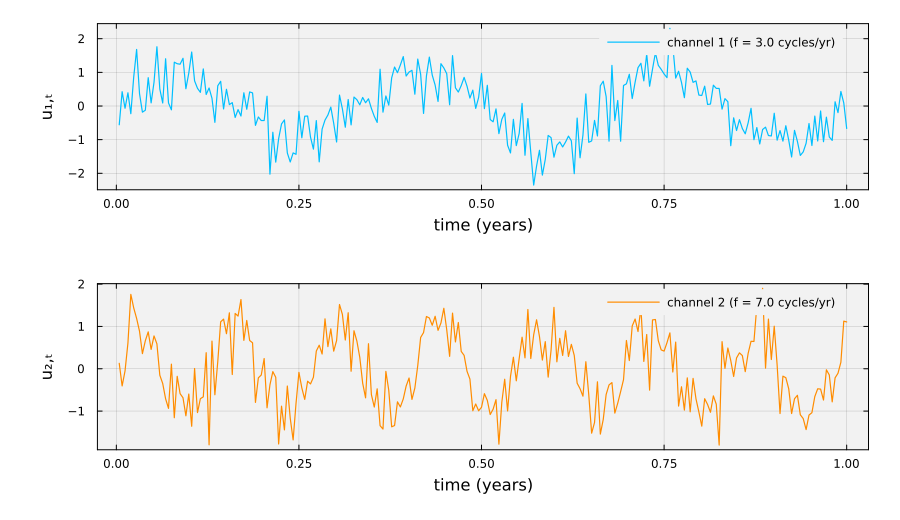

In [52]:
let
    # Plot only the first ~year of samples so individual oscillations are visible
    # instead of blurring together at full length.
    n_show = 252
    l = @layout [a; b]                                      # stack two panels vertically

    # Top panel: channel 1.
    p1 = plot(t_axis[1:n_show], U_full[1:n_show, 1];
        label = "channel 1 (f = $(SIGNAL_FREQS[1]) cycles/yr)",
        xlabel = "time (years)", ylabel = "u₁,ₜ",
        lw = 1.2, c = :deepskyblue,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)

    # Bottom panel: channel 2.
    p2 = plot(t_axis[1:n_show], U_full[1:n_show, 2];
        label = "channel 2 (f = $(SIGNAL_FREQS[2]) cycles/yr)",
        xlabel = "time (years)", ylabel = "u₂,ₜ",
        lw = 1.2, c = :darkorange,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)

    # Margins go on the outer plot() call (subplot margins would be silently dropped).
    plot(p1, p2; layout = l, size = (900, 520),
        left_margin = 12Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __What does the signal look like to a short-memory forecaster?__ Using only the two-panel plot above: (a) How many full oscillation periods of each channel fit in the displayed one-year window, and does that match the frequency you put in? (b) If you were trying to predict the next sample of channel 1 using only the immediate previous sample, how well could you do? How would this change if you instead used the last hundred samples? Answer without running any code.

___

## Task 2: Build and train the MIMO forecaster
In this task, we build a MIMO HiPPO-LegS SSM at per-channel hidden dimension `H_OBSERVER = 64` with two input channels and two output channels, and fit the readout $\bar{\mathbf{C}}$ by closed-form ridge regression on the first `TRAIN_FRACTION` of the aligned input-target pair at horizon `FORECAST_HORIZON`.

> __Data and Model:__
> 
> * __Data splits.__ We first form the forecast pair $(\mathbf{U}_{\text{input}}, \mathbf{U}_{\text{target}})$ from the full signal using [the `make_forecast_pair(...)` function](src/Compute.jl), which drops `FORECAST_HORIZON` rows so that row $t$ of the target is $\mathbf{u}_{t+k}$. We then split the pair into a training portion of size $\lfloor \texttt{TRAIN\_FRACTION}\cdot(T-k)\rfloor$ and a held-out continuation that the model never sees during training.
> * __Model fit.__ The MIMO LegS filter has $H = h\cdot d_{\text{in}} = 64\cdot 2 = 128$ hidden dimensions. The [`build(...)` method](src/Compute.jl) constructs the block-diagonal $(\mathbf{A}, \mathbf{B})$ matricies and their bilinear-discretized counterparts $(\bar{\mathbf{A}}, \bar{\mathbf{B}})$; the [`fit_C!(...)` function](src/Compute.jl) solves the stacked ridge normal equations for $\bar{\mathbf{C}}\in\mathbb{R}^{2\times 128}$ in one closed-form step. 

The code block below stores the trained model in `model::MyMimoLegSHippoModel`, the training portion of the input-target pair as `U_in_tr::Matrix{Float64}` and `U_tgt_tr::Matrix{Float64}`, and the held-out continuation as `U_in_te::Matrix{Float64}` and `U_tgt_te::Matrix{Float64}`.

In [53]:
model, U_in_tr, U_tgt_tr, U_in_te, U_tgt_te = let
    
    # Step 1: align the input and target at the chosen forecast horizon k.
    # make_forecast_pair drops the last k rows of U to build U_input, and the
    # first k rows to build U_target, so row t of U_target is u_{t+k}.
    (Uin, Utgt) = make_forecast_pair(U_full, FORECAST_HORIZON)
    T_pair = size(Uin, 1)                                  # number of aligned pairs (T - k)

    # Step 2: split chronologically. The training portion is the FIRST TRAIN_FRACTION
    # of the aligned pair; the held-out continuation is everything after it and is
    # never seen during training. This mirrors a real forecasting setup.
    n_train = floor(Int, TRAIN_FRACTION * T_pair)
    U_in_tr  = Uin[1:n_train, :]
    U_tgt_tr = Utgt[1:n_train, :]
    U_in_te  = Uin[(n_train + 1):end, :]
    U_tgt_te = Utgt[(n_train + 1):end, :]

    # Step 3: instantiate the MIMO LegS filter. `build` constructs the block-diagonal
    # (A, B) from the single-channel LegS block and returns the bilinear-discretized
    # pair (Ā, B̄) alongside a zero-initialized C and D.
    Random.seed!(42);                                      # stabilize any randomized init
    m = build(MyMimoLegSHippoModel; h = H_OBSERVER, d_in = 2, d_out = 2, Δt = Δt)

    # Step 4: learn the readout C̄ in ONE closed-form ridge solve. With (Ā, B̄) frozen,
    # the loss is quadratic in C̄ and decouples across output channels, so a single
    # (XᵀX + λI)⁻¹Xᵀ Y solve handles both channels at once (no SGD loop).
    fit_C!(m, U_in_tr, U_tgt_tr; λ = RIDGE_λ)

    # Log the fit geometry so students can verify the total hidden dimension
    # H = h * d_in and the train/test sizes.
    @info "trained MIMO forecaster" h=m.h d_in=m.d_in d_out=m.d_out H_total=size(m.Ā, 1) k=FORECAST_HORIZON n_train=n_train n_test=size(U_in_te, 1)
    (m, U_in_tr, U_tgt_tr, U_in_te, U_tgt_te)
end;

┌ Info: trained MIMO forecaster
│   h = 64
│   d_in = 2
│   d_out = 2
│   H_total = 128
│   k = 1
│   n_train = 839
│   n_test = 360
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X15sZmlsZQ==.jl:31


### In-sample forecast quality
With the readout fit, we roll the model forward on the training input to produce the in-sample forecast and check per-channel correlation and mean-squared error against the training target.

In [54]:
Ŷ_in = let
    
    # Roll the trained model forward on the training input and apply C̄ + D̄.
    # We only need Ŷ here; the first return is the hidden-state trajectory X, so we don't save that now.
    (_, Yhat) = solve(model, U_in_tr)

    # Per-channel Pearson correlation between the realized target u_{t+k}
    # and the model's forecast. ρ = 1 means a perfect monotone match;
    # ρ = 0 means no linear relationship.
    ρ1 = cor(U_tgt_tr[:, 1], Yhat[:, 1]) # correlation on channel 1
    ρ2 = cor(U_tgt_tr[:, 2], Yhat[:, 2]) # correlation on channel 2

    # Mean-squared error on the same pairs, useful alongside ρ because a forecast
    # can have high correlation but a wrong scale or bias.
    mse1 = mean((U_tgt_tr[:, 1] .- Yhat[:, 1]).^2) # MSE on channel 1
    mse2 = mean((U_tgt_tr[:, 2] .- Yhat[:, 2]).^2) # MSE on channel 2

    @info "in-sample forecast metrics" ρ_ch1=round(ρ1, digits=4) ρ_ch2=round(ρ2, digits=4) mse_ch1=round(mse1, sigdigits=4) mse_ch2=round(mse2, sigdigits=4)
    Yhat
end;

┌ Info: in-sample forecast metrics
│   ρ_ch1 = 0.8824
│   ρ_ch2 = 0.8368
│   mse_ch1 = 0.1692
│   mse_ch2 = 0.2066
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X20sZmlsZQ==.jl:18


### Visualize the in-sample forecast
We overlay the observed target and the forecaster's prediction for each channel on a small window of the training range so the tracking is visible.

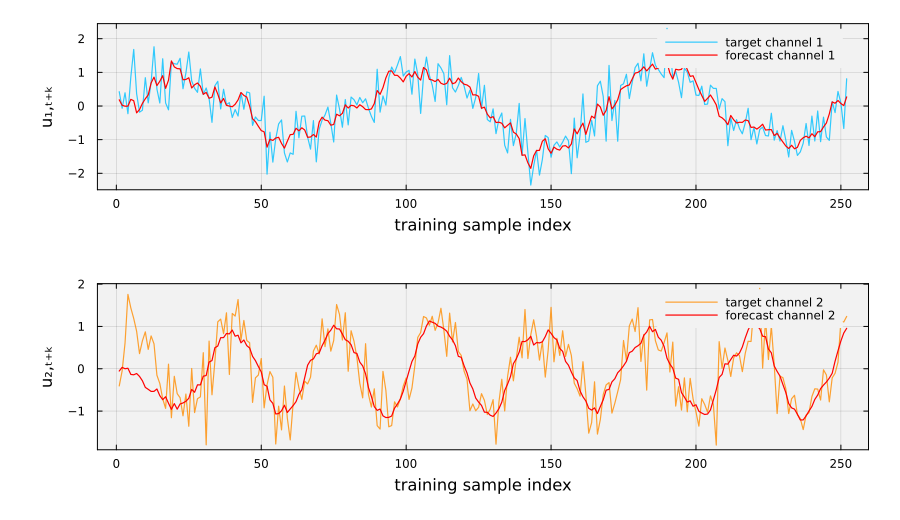

In [55]:
let
    # Show only ~252 training samples (bounded by the actual training length)
    # so the individual oscillations are visible and target/forecast lines can be compared.
    n_show = 252
    n_show = min(n_show, size(U_tgt_tr, 1))
    l = @layout [a; b]

    # Channel 1: target (blue) overlaid with forecast (red) on a short window.
    p1 = plot(U_tgt_tr[1:n_show, 1];
        label = "target channel 1",
        xlabel = "training sample index", ylabel = "u₁,ₜ₊ₖ",
        lw = 1.2, c = :deepskyblue, alpha = 0.8,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p1, Ŷ_in[1:n_show, 1]; label = "forecast channel 1", lw = 1.2, c = :red)

    # Channel 2: same pattern as channel 1.
    p2 = plot(U_tgt_tr[1:n_show, 2];
        label = "target channel 2",
        xlabel = "training sample index", ylabel = "u₂,ₜ₊ₖ",
        lw = 1.2, c = :darkorange, alpha = 0.8,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p2, Ŷ_in[1:n_show, 2]; label = "forecast channel 2", lw = 1.2, c = :red)

    plot(p1, p2; layout = l, size = (900, 520),
        left_margin = 12Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __What does the in-sample fit tell you about bandwidth coverage?__ Using only the overlay plot and the `@info` metrics above: (a) do both channels achieve high correlation, and are the reconstruction errors of comparable magnitude across channels? (b) What does this imply about whether `H_OBSERVER = 64` is large enough to span the bandwidth of both sinusoids at the sampling rate we chose?

___

## Task 3: Evaluate out-of-sample and sweep hidden dimension and horizon
In this task, we apply the trained model to the held-out continuation (out-of-sample) and then sweep the hidden dimension $h$ and the forecast horizon $k$ to study how forecast quality depends on each.

> __What do we expect?__ 
> 
> Because the signal is deterministic up to a small observation noise, the in-sample and out-of-sample forecast correlations should be close to one another at every $h$ once the basis (hidden dimension) is large enough. As $h$ shrinks, the hidden state cannot fully span the signal's dynamics and both correlations should drop together. As $k$ grows (the number of steps ahead), the forecast task generally gets harder. For this signal, however, every horizon we sweep ($k \le 20$ samples) is shorter than either channel's oscillation period ($\approx 84$ and $36$ samples), so correlations should stay close to their $k=1$ values across the sweep rather than falling off.

### Out-of-sample forecast
If we naively called [the `solve(model, U_in_te)` function](src/Compute.jl) on only the held-out split, the hidden state would start from $\mathbf{x}_{0} = \mathbf{0}$ and would need to re-absorb the signal's history before its predictions stabilize. 

Instead, we run the trained model forward through the entire concatenated train-then-test input in one pass, then keep only the predictions after the train/test boundary. The hidden state entering the OOS region has already absorbed the training history, so the reported metrics measure true generalization rather than filter-restart error.

In [56]:
Ŷ_oos, U_tgt_te_eval = let
    
    # CRITICAL: we do a SINGLE rollout over the concatenated train-then-test input
    # instead of calling solve(model, U_in_te) directly. The LegS basis has slow
    # modes whose time constants exceed 100 samples, so a fresh solve on the test
    # split starts with x₀ = 0 and would contaminate the first ~100 OOS predictions
    # with transient. Rolling through train first leaves the hidden state warm at
    # the train/test boundary, so the OOS slice reflects true generalization.
    U_full_pair = vcat(U_in_tr, U_in_te)
    (_, Yhat_full) = solve(model, U_full_pair)
    Yhat_te = Yhat_full[(size(U_in_tr, 1) + 1):end, :]      # keep only the OOS rows
    U_eval  = U_tgt_te

    # Per-channel correlation and MSE on the held-out continuation.
    ρ1 = cor(U_eval[:, 1], Yhat_te[:, 1])
    ρ2 = cor(U_eval[:, 2], Yhat_te[:, 2])
    mse1 = mean((U_eval[:, 1] .- Yhat_te[:, 1]).^2)
    mse2 = mean((U_eval[:, 2] .- Yhat_te[:, 2]).^2)

    @info "out-of-sample forecast metrics" ρ_ch1=round(ρ1, digits=4) ρ_ch2=round(ρ2, digits=4) mse_ch1=round(mse1, sigdigits=4) mse_ch2=round(mse2, sigdigits=4) T_eval=size(U_eval, 1)
    (Yhat_te, U_eval)
end;

┌ Info: out-of-sample forecast metrics
│   ρ_ch1 = 0.4205
│   ρ_ch2 = 0.4656
│   mse_ch1 = 20.89
│   mse_ch2 = 1.239
│   T_eval = 360
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-14/L14c/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X25sZmlsZQ==.jl:20


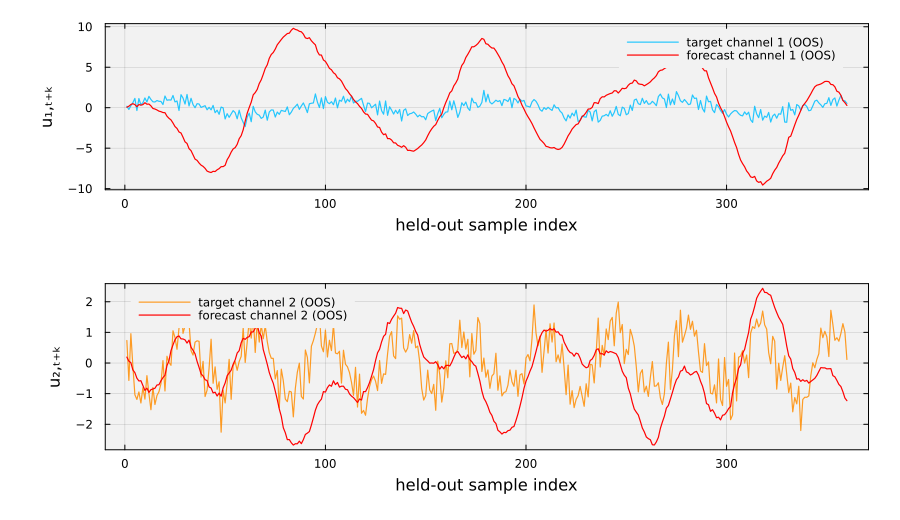

In [57]:
let
    # Overlay OOS target (blue/orange) and OOS forecast (red) for each channel.
    # Unlike the in-sample plot we show the full held-out window because the OOS segment
    # is already short (~360 samples).
    l = @layout [a; b]

    # Channel 1: target vs forecast, held-out.
    p1 = plot(U_tgt_te_eval[:, 1];
        label = "target channel 1 (OOS)",
        xlabel = "held-out sample index", ylabel = "u₁,ₜ₊ₖ",
        lw = 1.2, c = :deepskyblue, alpha = 0.85,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p1, Ŷ_oos[:, 1]; label = "forecast channel 1 (OOS)", lw = 1.2, c = :red)

    # Channel 2: target vs forecast, held-out.
    p2 = plot(U_tgt_te_eval[:, 2];
        label = "target channel 2 (OOS)",
        xlabel = "held-out sample index", ylabel = "u₂,ₜ₊ₖ",
        lw = 1.2, c = :darkorange, alpha = 0.85,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p2, Ŷ_oos[:, 2]; label = "forecast channel 2 (OOS)", lw = 1.2, c = :red)

    plot(p1, p2; layout = l, size = (900, 520),
        left_margin = 12Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Hidden-dimension sweep at a fixed horizon
With the horizon pinned at `FORECAST_HORIZON`, we vary the per-channel hidden dimension and record the per-channel in-sample and out-of-sample correlation.

In [58]:
sweep_h = let
    # Build the aligned forecast pair once at the fixed horizon; the pair does
    # not depend on h, only on k = FORECAST_HORIZON.
    (Uin, Utgt) = make_forecast_pair(U_full, FORECAST_HORIZON)
    T_pair = size(Uin, 1)
    n_train = floor(Int, TRAIN_FRACTION * T_pair)

    # Same train/test split as Task 2.
    Utr  = Uin[1:n_train, :]; Ttr  = Utgt[1:n_train, :]
    Ute  = Uin[(n_train + 1):end, :]; Tte  = Utgt[(n_train + 1):end, :]

    # Collect sweep results in a DataFrame: one row per hidden dimension h,
    # with per-channel in-sample and out-of-sample correlations.
    df = DataFrame(h = Int[], ρ_tr_ch1 = Float64[], ρ_tr_ch2 = Float64[],
                              ρ_te_ch1 = Float64[], ρ_te_ch2 = Float64[])

    for h in H_SWEEP
        # Rebuild and refit at each h. Each call is a fresh closed-form ridge
        # solve; there is no persistent state between iterations.
        m = build(MyMimoLegSHippoModel; h = h, d_in = 2, d_out = 2, Δt = Δt)
        fit_C!(m, Utr, Ttr; λ = RIDGE_λ)

        # SINGLE rollout on train-then-test (same warm-state trick as the OOS cell),
        # then split predictions back at the training boundary.
        (_, Yfull) = solve(m, vcat(Utr, Ute))
        n = size(Utr, 1)
        Yin = Yfull[1:n, :]
        Yte = Yfull[(n + 1):end, :]

        # Record the four correlations for this h.
        push!(df, (h,
                   cor(Ttr[:, 1], Yin[:, 1]), cor(Ttr[:, 2], Yin[:, 2]),
                   cor(Tte[:, 1], Yte[:, 1]), cor(Tte[:, 2], Yte[:, 2])))
    end

    # Render the sweep as a compact text table; floats rounded to 4 sig figs.
    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    df
end;

 ------- ---------- ---------- ---------- ----------
      h   ρ_tr_ch1   ρ_tr_ch2   ρ_te_ch1   ρ_te_ch2 
  Int64    Float64    Float64    Float64    Float64 
 ------- ---------- ---------- ---------- ----------
      2     0.3476      0.204      0.402     0.2748
      4     0.7661     0.5367     0.7867     0.4321
      8     0.8232     0.8103     0.8089      0.794
     16     0.8291     0.8244     0.6722     0.6745
     32     0.8508     0.8297     0.5849     0.6503
     64     0.8824     0.8368     0.4205     0.4656
    128     0.9175     0.8611   -0.07708    -0.1074
 ------- ---------- ---------- ---------- ----------


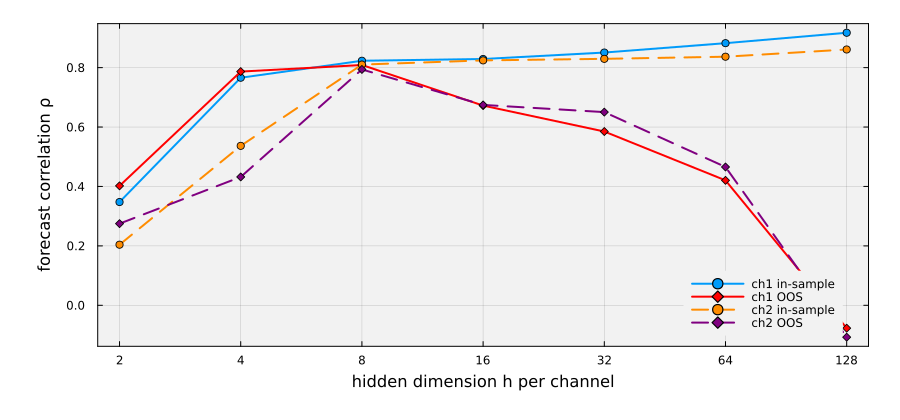

In [59]:
let
    # Channel 1 in-sample (solid blue) + OOS (solid red).
    # x-axis is log2 so geometric doubling of h (2, 4, 8, ...) is evenly spaced;
    # xticks are pinned to H_SWEEP so the labels are the actual integer values.
    p = plot(sweep_h.h, sweep_h.ρ_tr_ch1;
        label = "ch1 in-sample",  lw = 2, marker = :circle,
        xlabel = "hidden dimension h per channel", ylabel = "forecast correlation ρ",
        xscale = :log2, xticks = (H_SWEEP, string.(H_SWEEP)),
        legend = :bottomright,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p, sweep_h.h, sweep_h.ρ_te_ch1; label = "ch1 OOS",  lw = 2, marker = :diamond, c = :red)

    # Channel 2 uses dashed lines so the two channels are visually separable when they overlap.
    plot!(p, sweep_h.h, sweep_h.ρ_tr_ch2; label = "ch2 in-sample", lw = 2, marker = :circle,  c = :darkorange, ls = :dash)
    plot!(p, sweep_h.h, sweep_h.ρ_te_ch2; label = "ch2 OOS", lw = 2, marker = :diamond, c = :purple, ls = :dash)

    plot(p; size = (900, 420),
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Forecast-horizon sweep at a fixed hidden dimension
With the hidden dimension pinned at `H_OBSERVER`, we vary the forecast horizon $k$ and record the per-channel in-sample and out-of-sample correlation.

In [60]:
sweep_k = let
    
    # Collect sweep results: one row per horizon k, with per-channel in-sample
    # and out-of-sample correlations.
    df = DataFrame(k = Int[], ρ_tr_ch1 = Float64[], ρ_tr_ch2 = Float64[],
                              ρ_te_ch1 = Float64[], ρ_te_ch2 = Float64[])

    for k in K_SWEEP
        # The aligned pair (U_input, U_target) DOES depend on k, so rebuild it at every iteration.
        # Increasing k removes k rows from each matrix (T_pair = T - k).
        (Uin, Utgt) = make_forecast_pair(U_full, k)
        T_pair = size(Uin, 1)
        n_train = floor(Int, TRAIN_FRACTION * T_pair)

        # Train/test split at k-specific n_train.
        Utr  = Uin[1:n_train, :]; Ttr  = Utgt[1:n_train, :]
        Ute  = Uin[(n_train + 1):end, :]; Tte  = Utgt[(n_train + 1):end, :]

        # Rebuild and refit at the fixed H_OBSERVER.
        m = build(MyMimoLegSHippoModel; h = H_OBSERVER, d_in = 2, d_out = 2, Δt = Δt)
        fit_C!(m, Utr, Ttr; λ = RIDGE_λ)

        # Single warm-state rollout, then split predictions at the training boundary.
        (_, Yfull) = solve(m, vcat(Utr, Ute))
        n = size(Utr, 1)
        Yin = Yfull[1:n, :]
        Yte = Yfull[(n + 1):end, :]

        push!(df, (k,
                   cor(Ttr[:, 1], Yin[:, 1]), cor(Ttr[:, 2], Yin[:, 2]),
                   cor(Tte[:, 1], Yte[:, 1]), cor(Tte[:, 2], Yte[:, 2])))
    end

    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    df
end;

 ------- ---------- ---------- ---------- ----------
      k   ρ_tr_ch1   ρ_tr_ch2   ρ_te_ch1   ρ_te_ch2 
  Int64    Float64    Float64    Float64    Float64 
 ------- ---------- ---------- ---------- ----------
      1     0.8824     0.8368     0.4205     0.4656
      2     0.8659     0.8354     0.4511     0.5881
      5     0.8528     0.8371     0.4231     0.6755
     10     0.8492     0.8386    0.09862     0.6953
     20     0.8492     0.8347     0.2792     0.5322
 ------- ---------- ---------- ---------- ----------


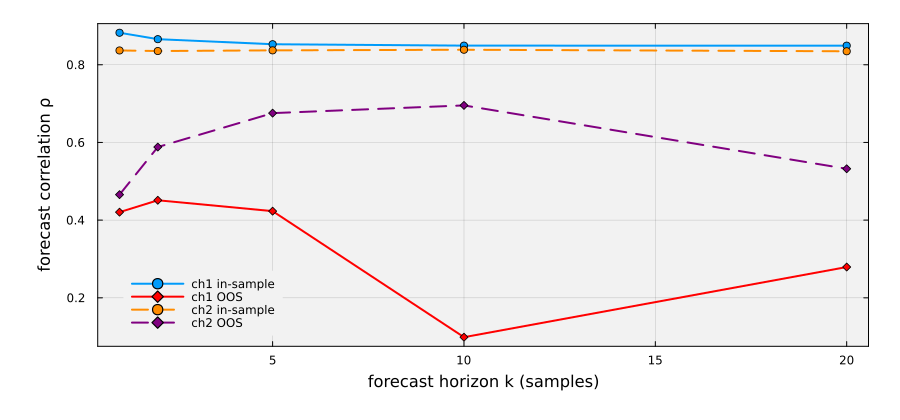

In [61]:
let
    # Plot correlation as a function of the forecast horizon k.
    # Linear x-axis (unlike the h-sweep), since k values in K_SWEEP are not geometrically spaced.
    p = plot(sweep_k.k, sweep_k.ρ_tr_ch1;
        label = "ch1 in-sample",  lw = 2, marker = :circle,
        xlabel = "forecast horizon k (samples)", ylabel = "forecast correlation ρ",
        legend = :bottomleft,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent)
    plot!(p, sweep_k.k, sweep_k.ρ_te_ch1; label = "ch1 OOS",  lw = 2, marker = :diamond, c = :red)

    # Channel 2 is dashed so the channels are distinguishable where the curves overlap.
    plot!(p, sweep_k.k, sweep_k.ρ_tr_ch2; label = "ch2 in-sample", lw = 2, marker = :circle,  c = :darkorange, ls = :dash)
    plot!(p, sweep_k.k, sweep_k.ρ_te_ch2; label = "ch2 OOS", lw = 2, marker = :diamond, c = :purple, ls = :dash)

    plot(p; size = (900, 420),
        left_margin = 12Plots.mm, bottom_margin = 10Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
* __What do the two sweeps tell you about the signal?__ Using only the two sweep tables and their plots (no retraining): (a) Does forecast correlation saturate close to one past some hidden dimension, and at roughly what value of $h$ does the saturation happen for each channel? (b) Does forecast correlation fall monotonically as $k$ grows, and do the two channels degrade at comparable rates or at different rates? Put the two observations together: for this synthetic signal, is the limiting factor the model's memory (small $h$) or the intrinsic predictability of the signal (large $k$)?

___

## Summary
This notebook fit a two-input two-output MIMO HiPPO-LegS SSM to a noisy two-channel oscillator signal, trained the readout by closed-form ridge regression on an aligned input-target pair at forecast horizon one, and evaluated on a held-out continuation. The same infrastructure then let us sweep the per-channel hidden dimension and the forecast horizon to see how each knob moved the forecast correlation.

> __Key Takeaways:__
>
> * **The MIMO forecaster inherits the hidden-dimension scaling of the SISO memorize task:** As the per-channel hidden dimension grows from small to large, in-sample and out-of-sample forecast correlations rise together and saturate near one once the LegS basis can span both sinusoidal frequencies. Undersizing the basis is the dominant failure mode at small hidden dimension.
> * **Multi-output ridge is free on top of single-output ridge:** The second output channel adds no training time beyond the one-column ridge solve, because the Gram matrix is shared and only the right-hand side changes. This is why scaling from SISO to MIMO is almost trivial in practice.
> * **Forecast correlation at horizons shorter than the oscillation period stays high:** Every tested horizon ($k = 1, 2, 5, 10, 20$ samples) is shorter than either channel's oscillation period ($\approx 84$ and $36$ samples), so the forecaster stays inside the regime where the signal remains highly predictable and correlations hold near one across the sweep. For horizons much longer than the period, or for signals with shorter decorrelation times, correlation would fall toward zero.

Taken together, the two sweeps show that a modest per-channel LegS basis combined with one closed-form ridge solve is enough to forecast a structured multi-channel signal with near-perfect correlation, and they make explicit the two regimes, memory-limited and predictability-limited, that any forecaster of this form has to sit between.
___